In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sun.src.sun_post_process import PostProcessSun
from utils.styles import *
import pickle

In [19]:
inputFiles = [
    '../single_block/normal_geometry/Output/results_30_10.pkl',
    '../multi_block/Output/results_30_10.pkl',
]

inputLabels = [
    r'Single-block',
    r'Multiblock'
]

In [20]:
pps = []
for inputFile in inputFiles:
    pps.append(PostProcessSun(inputFile))
    pps[-1].extract_eigenfields()

Selected mode: 6, frequency: 31297.202652
Selected mode: 2, frequency: 31297.202694


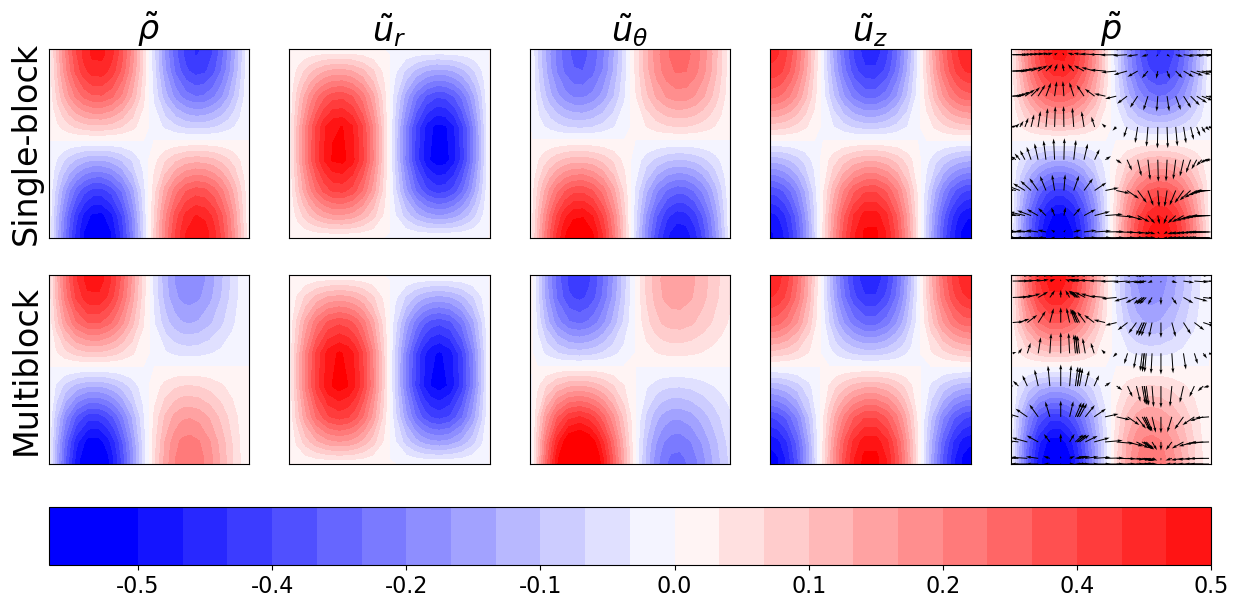

In [21]:
fig, axs = plt.subplots(2, 5, figsize=(15, 7), sharey=True)
modes_map = cm.bwr
save_filename = 'eigenfunctions_comparison'
titles = [
        r'$\tilde{\rho}$',
        r'$\tilde{u}_{r}$',
        r'$\tilde{u}_{\theta}$',
        r'$\tilde{u}_{z}$',
        r'$\tilde{p}$',
    ]

for ipp,pp in enumerate(pps):
    z = pp.data['AxialCoords']
    r = pp.data['RadialCoords']
    
    eigs = pp.data['Eigenfrequencies'].real
    imode = np.argmin(np.abs(eigs-31000))
    print('Selected mode: %i, frequency: %f' % (imode, eigs[imode]))
    mode = pp.eigenfields[imode]
    rs = mode.eigenfrequency.real
    df = mode.eigenfrequency.imag

    fields = [
        mode.eigen_rho,
        mode.eigen_ur*(-1),
        mode.eigen_utheta*(-1),
        mode.eigen_uz*(-1),
        mode.eigen_p,
    ]

    vmin, vmax = -0.5, 0.5
    for i, (ax, field, title) in enumerate(zip(axs[ipp,:], fields, titles)):
        cf = ax.contourf(
            z, r, field,
            levels=30,
            cmap=modes_map,
            vmin=vmin,
            vmax=vmax
        )

        if ipp==0:
            ax.set_title(title)

        # Keep x-label only for bottom row (if needed adjust condition)
        # ax.set_xlabel(r'$z$')
        ax.set_xticks([])
        ax.set_yticks([])

    # Create ONE shared colorbar
    if ipp==0:
        cbar = fig.colorbar(
            cf,
            ax=axs,
            format='%.1f',
            orientation='horizontal',
            pad=0.08   # increase = move further away
        )
    ax.quiver(
            z[1:-1], r[1:-1], fields[3][1:-1], fields[1][1:-1],
            angles='xy', scale_units='xy', scale=12, width=0.005
        )

for ipp, pp in enumerate(pps):
    axs[ipp, 0].set_ylabel(inputLabels[ipp])

plt.savefig(
    'pictures/' + save_filename + '_modes_%i_%i_%i.pdf' %
    (pp.nStream, pp.nSpan, imode),
    bbox_inches='tight'
)


In [22]:
with open('analytical/analytical_eigenvalues.pkl', 'rb') as f:
    analytical = pickle.load(f)

analytical

array([13450.28377557, 21077.00407234, 26760.68653023, 31296.39453022,
       35049.4912513 , 40102.05348165, 41996.32182585, 43260.89065735,
       51533.78888435])

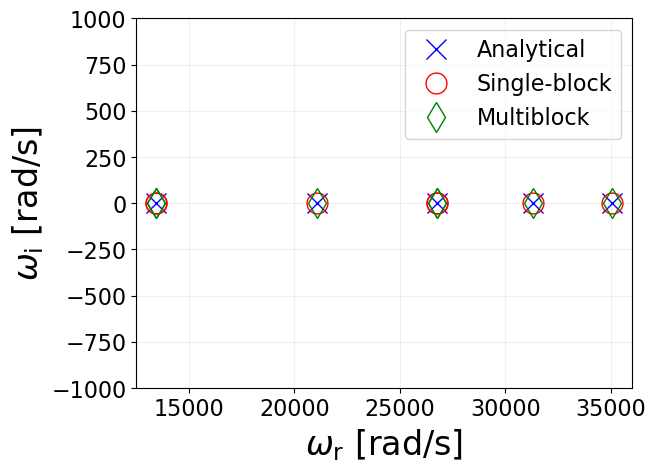

In [23]:
plt.figure()
plt.plot(analytical, analytical*0, 'x', mfc='none', ms=15, label='Analytical', c='blue')

# modes 3 and 4 are spurious
markers = ['ro', 'gd']


for ipp, pp in enumerate(pps):
    eigs = pp.data['Eigenfrequencies']
    for ii,eig in enumerate(eigs):
        if ii == 0:
            plt.plot(eig.real, eig.imag, markers[ipp], mfc='none', ms=15, label=inputLabels[ipp])
        else:
            plt.plot(eig.real, eig.imag, markers[ipp], mfc='none', ms=15)
plt.legend()
plt.grid(alpha=0.2)
plt.xlim([12500, 36000])
plt.ylim([-1000, 1000])
plt.xlabel(r'$\omega_{\rm r}$ [rad/s]')
plt.ylabel(r'$\omega_{\rm i}$ [rad/s]')
plt.savefig('pictures/eigenvalues_single_multi_comparison.pdf', bbox_inches='tight')
plt.show()